In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(100,256,4,1,0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        return self.main(x)

generator = Generator().to(device)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,1,8),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.main(x).view(-1,1)

discriminator = Discriminator().to(device)

In [ ]:
criterion = nn.BCELoss()

g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002)

In [ ]:
for epoch in range(3):
    for i,(real,_) in enumerate(loader):

        real = real.to(device)
        batch = real.size(0)

        # Train Discriminator
        noise = torch.randn(batch,100,1,1).to(device)
        fake = generator(noise)

        real_labels = torch.ones(batch,1).to(device)
        fake_labels = torch.zeros(batch,1).to(device)

        d_real = discriminator(real)
        d_fake = discriminator(fake.detach())

        d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        output = discriminator(fake)
        g_loss = criterion(output, real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        if i > 100:
            break

    print(f"Epoch {epoch+1} completed")

Epoch 1 completed
Epoch 2 completed
Epoch 3 completed


In [ ]:
noise = torch.randn(10,100,1,1).to(device)

with torch.no_grad():
    fake_images = generator(noise).cpu()

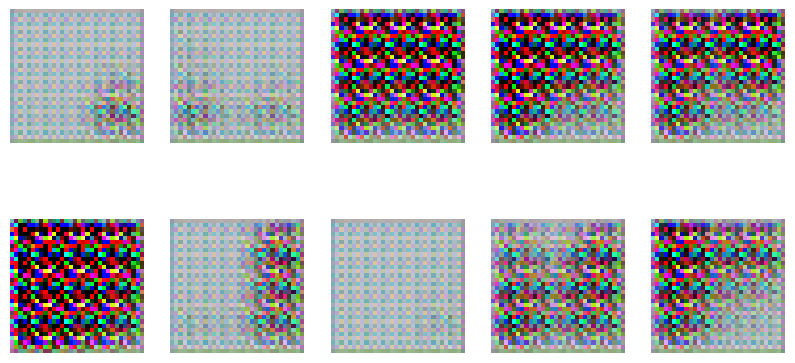

In [ ]:
fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    img = (fake_images[i]+1)/2
    ax.imshow(img.permute(1,2,0))
    ax.axis('off')

plt.show()

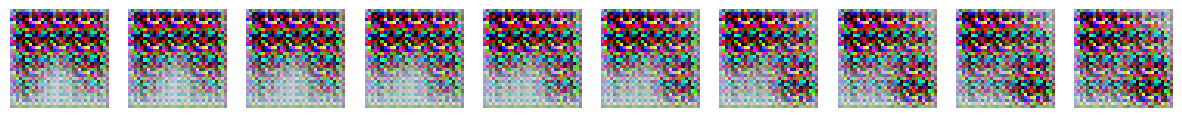

In [ ]:
z1 = torch.randn(1,100,1,1).to(device)
z2 = torch.randn(1,100,1,1).to(device)

alphas = torch.linspace(0,1,10)

fig, axes = plt.subplots(1,10, figsize=(15,3))

with torch.no_grad():
    for i, alpha in enumerate(alphas):
        z = alpha*z1 + (1-alpha)*z2
        img = generator(z).cpu()[0]
        img = (img+1)/2
        axes[i].imshow(img.permute(1,2,0))
        axes[i].axis('off')

plt.show()